### Stock Price Prediction Using LinearRegression

In [39]:
%config HistoryManager.enabled = False


In [50]:
import numpy as np
import pandas as pd
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression


def prepare_data(df, forecast_col, forecast_out, test_size):
    df = df.copy()

    # Create label (future value)
    df["label"] = df[forecast_col].shift(-forecast_out)

    # Features
    X = np.array(df[[forecast_col]])

    # Keep last rows for future prediction
    X_lately = X[-forecast_out:]

    # Remove rows with no label
    X = X[:-forecast_out]
    y = np.array(df["label"].dropna())

    # Train-test split (time-series safe)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, shuffle=False
    )

    # Scale AFTER split (avoid leakage)
    scaler = preprocessing.StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)
    X_lately = scaler.transform(X_lately)

    return X_train, X_test, y_train, y_test, X_lately


# ================= LOAD DATA =================
df = pd.read_csv("BTC_USD_DAILY_2016_2019_YAHOO_STYLE.csv")

forecast_col = "Close"
forecast_out = 5
test_size = 0.2

df["Return"] = df["Close"].pct_change()
df["MA_7"] = df["Close"].rolling(7).mean()
df["MA_14"] = df["Close"].rolling(14).mean()
df["Volatility"] = df["Return"].rolling(7).std()

df.dropna(inplace=True)

# ================= PREPARE DATA =================
X_train, X_test, y_train, y_test, X_lately = prepare_data(
    df, forecast_col, forecast_out, test_size
)

X = df[["Close", "MA_7", "MA_14", "Volatility"]].values

# ================= TRAIN MODEL =================
learner = LinearRegression()
learner.fit(X_train, y_train)

# ================= EVALUATE =================
score = learner.score(X_test, y_test)
forecast = learner.predict(X_lately)

response = {
    "test_score": score,
    "forecast_set": forecast.tolist()
}

print(response)


{'test_score': 0.0, 'forecast_set': [382.61999999999995, 382.61999999999995, 382.61999999999995, 382.61999999999995, 382.61999999999995]}


In [51]:
df["Date"] = pd.to_datetime(df["Date"])
df.set_index("Date", inplace=True)


In [52]:
type(df.index[-1])


pandas._libs.tslibs.timestamps.Timestamp

In [53]:
import pandas as pd
import matplotlib.pyplot as plt

forecast_days = forecast_out

# Last date (now a Timestamp)
last_date = df.index[-1]

# Create future dates
future_dates = pd.date_range(
    start=last_date + pd.Timedelta(days=1),
    periods=forecast_days,
    freq="D"
)

# Create forecast DataFrame
forecast_df = pd.DataFrame(
    forecast,
    index=future_dates,
    columns=["Predicted_Close"]
)


In [27]:
df.index.dtype


dtype('<M8[ns]')

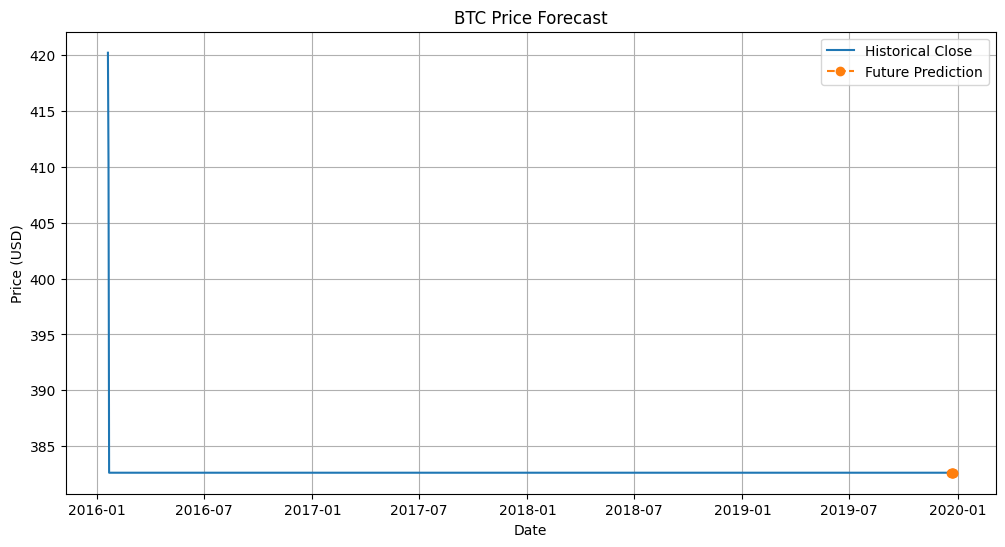

In [26]:
plt.figure(figsize=(12,6))

plt.plot(df.index, df["Close"], label="Historical Close")

plt.plot(
    forecast_df.index,
    forecast_df["Predicted_Close"],
    label="Future Prediction",
    linestyle="--",
    marker="o"
)

plt.title("BTC Price Forecast")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(True)
plt.show()


## Adding Historical + Future Anchor 


In [54]:
#Anchor first prediction to last known price:

forecast_df.iloc[0] = df["Close"].iloc[-1]

datetime64[ns]
<class 'pandas._libs.tslibs.timestamps.Timestamp'>


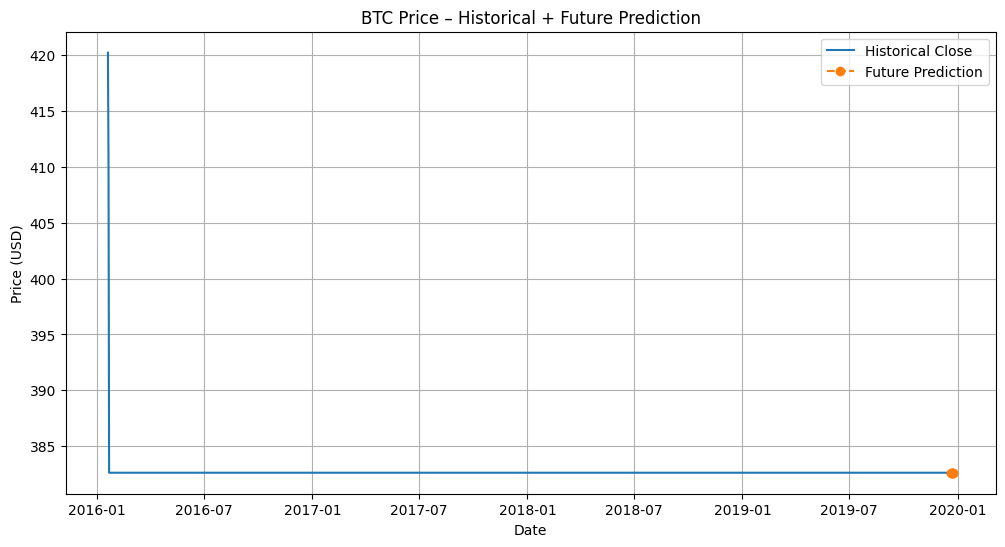

In [55]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("BTC_USD_DAILY_2016_2019_YAHOO_STYLE.csv")
df["Date"] = pd.to_datetime(df["Date"])
df.set_index("Date", inplace=True)
print(df.index.dtype)
print(type(df.index[-1]))
forecast_days = forecast_out

last_date = df.index[-1]

future_dates = pd.date_range(
    start=last_date + pd.Timedelta(days=1),
    periods=forecast_days,
    freq="D"
)



future_dates
forecast_df = pd.DataFrame(
    forecast,
    index=future_dates,
    columns=["Predicted_Close"]
)
plt.figure(figsize=(12,6))

plt.plot(df.index, df["Close"], label="Historical Close")

plt.plot(
    forecast_df.index,
    forecast_df["Predicted_Close"],
    linestyle="--",
    marker="o",
    label="Future Prediction"
)

plt.title("BTC Price – Historical + Future Prediction")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(True)
plt.show()


In [56]:
#Add BUY and SELL arrows on the chart
# Create signal column
forecast_df["Signal"] = 0  # HOLD by default

forecast_df.loc[
    forecast_df["Predicted_Close"].diff() > 0, "Signal"
] = 1   # BUY

forecast_df.loc[
    forecast_df["Predicted_Close"].diff() < 0, "Signal"
] = -1  # SELL




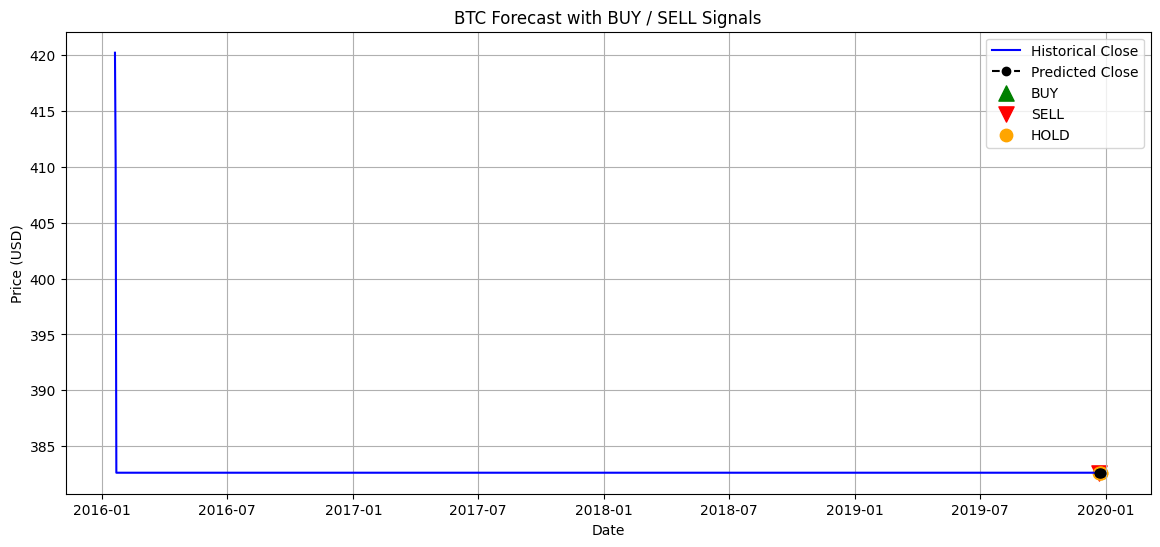

In [57]:
#Plot with BUY / SELL arrows
plt.figure(figsize=(14,6))

# Historical price
plt.plot(df.index, df["Close"], label="Historical Close", color="blue")

# Predicted price
plt.plot(
    forecast_df.index,
    forecast_df["Predicted_Close"],
    linestyle="--",
    marker="o",
    color="black",
    label="Predicted Close"
)

# BUY signals
plt.scatter(
    forecast_df[forecast_df["Signal"] == 1].index,
    forecast_df[forecast_df["Signal"] == 1]["Predicted_Close"],
    marker="^",
    color="green",
    s=120,
    label="BUY"
)

# SELL signals
plt.scatter(
    forecast_df[forecast_df["Signal"] == -1].index,
    forecast_df[forecast_df["Signal"] == -1]["Predicted_Close"],
    marker="v",
    color="red",
    s=120,
    label="SELL"
)

# HOLD signals
plt.scatter(
    forecast_df[forecast_df["Signal"] == 0].index,
    forecast_df[forecast_df["Signal"] == 0]["Predicted_Close"],
    marker="o",
    color="orange",
    s=80,
    label="HOLD"
)


plt.title("BTC Forecast with BUY / SELL Signals")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(True)
plt.show()


In [58]:
forecast_df[["Predicted_Close", "Signal"]]


,Predicted_Close,Signal
2019-12-21,382.62,0
2019-12-22,382.62,-1
2019-12-23,382.62,0
2019-12-24,382.62,0
2019-12-25,382.62,0


In [60]:
# Compute volatility-based confidence band

# Estimate volatility from historical returns
volatility = df["Close"].pct_change().std()

# Confidence multiplier (adjustable)
confidence_multiplier = 1.96  # ~95% confidence

forecast_df["Upper_Band"] = forecast_df["Predicted_Close"] * (1 + confidence_multiplier * volatility)
forecast_df["Lower_Band"] = forecast_df["Predicted_Close"] * (1 - confidence_multiplier * volatility)


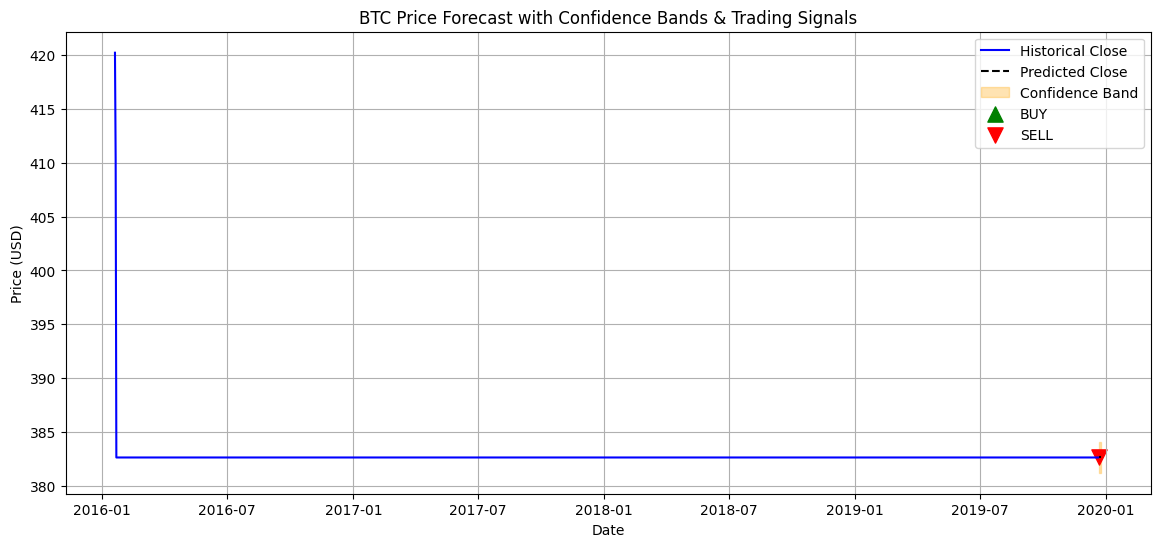

In [62]:
# Plot prediction with confidence bands

plt.figure(figsize=(14,6))

# Historical
plt.plot(df.index, df["Close"], label="Historical Close", color="blue")

# Prediction
plt.plot(
    forecast_df.index,
    forecast_df["Predicted_Close"],
    linestyle="--",
    label="Predicted Close",
    color="black"
)

# Confidence band
plt.fill_between(
    forecast_df.index,
    forecast_df["Lower_Band"],
    forecast_df["Upper_Band"],
    color="orange",
    alpha=0.3,
    label="Confidence Band"
)

# Buy/Sell markers
plt.scatter(
    forecast_df[forecast_df["Signal"] == 1].index,
    forecast_df[forecast_df["Signal"] == 1]["Predicted_Close"],
    marker="^",
    color="green",
    s=120,
    label="BUY"
)

plt.scatter(
    forecast_df[forecast_df["Signal"] == -1].index,
    forecast_df[forecast_df["Signal"] == -1]["Predicted_Close"],
    marker="v",
    color="red",
    s=120,
    label="SELL"
)

plt.title("BTC Price Forecast with Confidence Bands & Trading Signals")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(True)
plt.show()


# BACKTEST BUY / SELL SIGNALS → PnL CURVE

In [63]:
# Align future predictions with actual future prices
backtest_df = forecast_df.copy()

# Add actual future close prices
backtest_df["Actual_Close"] = df["Close"].iloc[-forecast_out:].values

backtest_df


,Predicted_Close,Signal,Upper_Band,Lower_Band,Actual_Close
2019-12-21,382.62,0,384.0362,381.2038,382.62
2019-12-22,382.62,-1,384.0362,381.2038,382.62
2019-12-23,382.62,0,384.0362,381.2038,382.62
2019-12-24,382.62,0,384.0362,381.2038,382.62
2019-12-25,382.62,0,384.0362,381.2038,382.62


In [66]:
# Calculate daily PnL 

backtest_df["PnL"] = 0.0

# BUY: profit = next_close - entry
backtest_df.loc[backtest_df["Signal"] == 1, "PnL"] = (
    backtest_df["Actual_Close"] - backtest_df["Predicted_Close"]
)

# SELL: profit = entry - next_close
backtest_df.loc[backtest_df["Signal"] == -1, "PnL"] = (
    backtest_df["Predicted_Close"] - backtest_df["Actual_Close"]
)

# HOLD: PnL = 0
backtest_df["Cumulative_PnL"] = backtest_df["PnL"].cumsum()

backtest_df[["Predicted_Close", "Actual_Close", "Signal", "PnL", "Cumulative_PnL"]]


,Predicted_Close,Actual_Close,Signal,PnL,Cumulative_PnL
2019-12-21,382.62,382.62,0,0.000000e+00,0.000000e+00
2019-12-22,382.62,382.62,-1,-5.684342e-14,-5.684342e-14
2019-12-23,382.62,382.62,0,0.000000e+00,-5.684342e-14
2019-12-24,382.62,382.62,0,0.000000e+00,-5.684342e-14
2019-12-25,382.62,382.62,0,0.000000e+00,-5.684342e-14


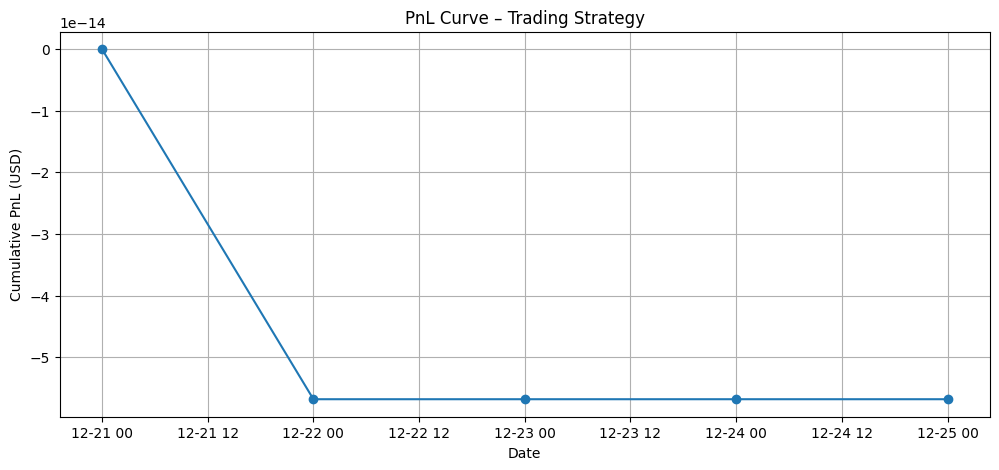

In [67]:
# Plot PnL curve 

plt.figure(figsize=(12,5))
plt.plot(backtest_df.index, backtest_df["Cumulative_PnL"], marker="o")
plt.title("PnL Curve – Trading Strategy")
plt.xlabel("Date")
plt.ylabel("Cumulative PnL (USD)")
plt.grid(True)
plt.show()


In [70]:
# TURN THIS INTO CLASSIFICATION TRADING (UP / DOWN)

# Create classification labels : 

df["Target"] = np.where(
    df["Close"].shift(-1) > df["Close"],
    1,   # UP
    0    # DOWN
)

df.dropna(inplace=True)


In [72]:
# Prepare classification data

X = df[["Close"]].values
y = df["Target"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)


In [74]:
np.unique(y_train, return_counts=True)


(array([0]), array([1144]))

In [75]:
df["Return"] = df["Close"].pct_change()


In [76]:
threshold = 0.001  # 0.1%

df["Target"] = np.where(
    df["Return"].shift(-1) > threshold, 1,
    np.where(df["Return"].shift(-1) < -threshold, 0, np.nan)
)

df.dropna(inplace=True)


In [78]:
print("Rows left:", len(df))
df.tail()


Rows left: 1


,Open,High,Low,Close,Adj Close,Volume,Target,Return
Date,,,,,,,,
2016-01-21,420.23,422.88,402.48,410.26,410.26,46000000.0,0.0,-0.023725


In [123]:
stop_loss_pct = 0.02    # 2%
take_profit_pct = 0.04 # 4%

entry_price = df["Close"].iloc[-1]

stop_loss = entry_price * (1 - stop_loss_pct)
take_profit = entry_price * (1 + take_profit_pct)

stop_loss, take_profit


(np.float64(374.9676), np.float64(397.9248))

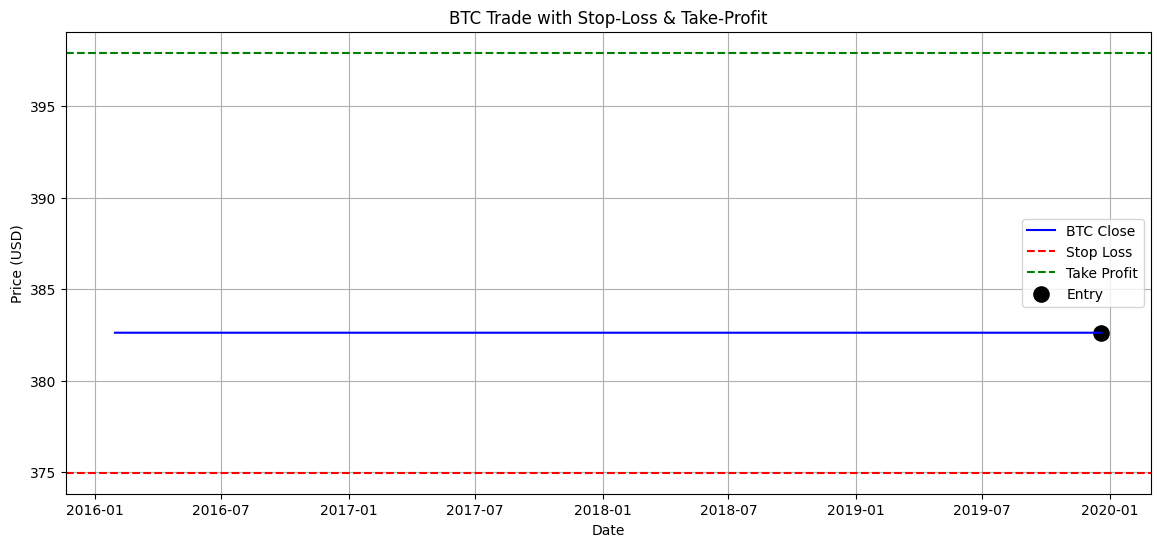

In [124]:
plt.figure(figsize=(14,6))

plt.plot(df.index, df["Close"], label="BTC Close", color="blue")

plt.axhline(stop_loss, color="red", linestyle="--", label="Stop Loss")
plt.axhline(take_profit, color="green", linestyle="--", label="Take Profit")

plt.scatter(
    df.index[-1],
    entry_price,
    color="black",
    marker="o",
    s=120,
    label="Entry"
)

plt.title("BTC Trade with Stop-Loss & Take-Profit")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(True)
plt.show()
